# EV Market Segmentation — Washington State
### Research question: What distinct EV market segments exist in Washington State's registered vehicle population?

**Dataset:** Washington State Department of Licensing — Electric Vehicle Population Data  
**Methods:** K-Means Clustering (primary) · Agglomerative Hierarchical Clustering (comparison)  
**Course:** DATA110 — Machine Learning · Golden Gate University  

---
| Cell | Content |
|------|--------|
| 1 | Imports |
| 2 | Load data |
| 3 | Feature engineering |
| 4 | Working dataset |
| 5 | EDA — 6-panel figure |
| 6 | EDA — Correlation heatmap |
| 7 | Scale features + PCA |
| 8 | Optimal k (elbow + silhouette) |
| 9 | K-Means (k=4) |
| 10 | Agglomerative + Dendrogram |
| 11 | Algorithm comparison |
| 12 | Cluster profiling + naming |
| 13 | PCA scatter plot |
| 14 | Cluster dashboard |
| 15 | Geographic analysis |
| 16 | Final summary |

## Cell 1 — Imports

In [3]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

RANDOM_SEED = 42
K_BEST      = 4
BEV_COLOR   = '#2E86AB'
PHEV_COLOR  = '#E84855'
CMAP4       = ['#2E86AB', '#E84855', '#F4A261', '#2EC4B6']

print("All libraries imported successfully.")

All libraries imported successfully.


## Cell 2 — Load Data

In [4]:
# =============================================================================
# CELL 2 — LOAD DATA
# Only columns we actually need are loaded.
# =============================================================================
COLS = ['Model Year', 'Make', 'Electric Vehicle Type',
        'Electric Range', 'County', 'City']

df = pd.read_csv('Electric_Vehicle_Population_Data.csv', usecols=COLS)

print(f"Shape           : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nElectric Vehicle Type breakdown:")
print(df['Electric Vehicle Type'].value_counts())
print(f"\nZero Electric Range : {(df['Electric Range']==0).sum():,}"
      f"  ({(df['Electric Range']==0).mean()*100:.1f}%)")
print(f"  → No range data — will be excluded from clustering.")
print(f"\nModel Year range : {df['Model Year'].min()} — {df['Model Year'].max()}")
print(f"Unique Makes     : {df['Make'].nunique()}")
print(f"Unique Counties  : {df['County'].nunique()}")

df.head()

Shape           : 166,800 rows  x  6 columns
Duplicate rows  : 140703

Missing values per column:
County                   5
City                     5
Model Year               0
Make                     0
Electric Vehicle Type    0
Electric Range           0
dtype: int64

Electric Vehicle Type breakdown:
Electric Vehicle Type
Battery Electric Vehicle (BEV)            130293
Plug-in Hybrid Electric Vehicle (PHEV)     36507
Name: count, dtype: int64

Zero Electric Range : 83,517  (50.1%)
  → No range data — will be excluded from clustering.

Model Year range : 1997 — 2024
Unique Makes     : 39
Unique Counties  : 187


,County,City,Model Year,Make,Electric Vehicle Type,Electric Range
0,Yakima,Yakima,2014,FIAT,Battery Electric Vehicle (BEV),87
1,Thurston,Olympia,2017,TESLA,Battery Electric Vehicle (BEV),200
2,King,Renton,2023,BMW,Plug-in Hybrid Electric Vehicle (PHEV),20
3,Snohomish,Bothell,2023,RIVIAN,Battery Electric Vehicle (BEV),0
4,King,Kent,2020,TESLA,Battery Electric Vehicle (BEV),322


## Cell 3 — Feature Engineering

Four features drive the clustering:

| Feature | Description | Why it matters |
|---------|-------------|---------------|
| `Model Year` | Year of manufacture | Captures technology generation |
| `Electric Range` | EPA-rated miles on electric power | Primary market discriminator |
| `Is_BEV` | 1 = Battery EV, 0 = Plug-in Hybrid | Powertrain commitment |
| `Is_Luxury` | 1 = premium brand, 0 = mass-market | Price-segment proxy |

> **Base MSRP excluded** — 98% of values are zero in this dataset, so it carries no information.

In [5]:
# =============================================================================
# CELL 3 — FEATURE ENGINEERING
# =============================================================================
LUXURY_BRANDS = {
    'TESLA', 'BMW', 'AUDI', 'MERCEDES-BENZ', 'PORSCHE',
    'VOLVO', 'JAGUAR', 'LAND ROVER', 'LEXUS', 'CADILLAC'
}

df['Is_BEV']    = df['Electric Vehicle Type'].str.contains('Battery').astype(int)
df['Is_Luxury'] = df['Make'].isin(LUXURY_BRANDS).astype(int)

print("Is_BEV distribution (1=BEV, 0=PHEV):")
print(df['Is_BEV'].value_counts().rename({1:'BEV', 0:'PHEV'}))

print("\nIs_Luxury distribution (1=Luxury, 0=Mass-Market):")
print(df['Is_Luxury'].value_counts().rename({1:'Luxury', 0:'Mass-Market'}))

print("\nTop 5 luxury makes in dataset:")
print(df[df['Is_Luxury']==1]['Make'].value_counts().head())

Is_BEV distribution (1=BEV, 0=PHEV):
Is_BEV
BEV     130293
PHEV     36507
Name: count, dtype: int64

Is_Luxury distribution (1=Luxury, 0=Mass-Market):
Is_Luxury
Luxury         92721
Mass-Market    74079
Name: count, dtype: int64

Top 5 luxury makes in dataset:
Make
TESLA            74834
BMW               7196
VOLVO             3962
AUDI              3464
MERCEDES-BENZ     1342
Name: count, dtype: int64


## Cell 4 — Working Dataset

**Step 1:** Remove records where `Electric Range == 0`. These vehicles have no range data — including them would create a degenerate spike at zero that dominates the clustering and produces meaningless results.

**Step 2:** Draw a stratified 30,000-record sample (stratified on `Is_BEV`) so the BEV/PHEV ratio is preserved.

In [6]:
# =============================================================================
# CELL 4 — WORKING DATASET
# =============================================================================

# Step 1: Remove zero Electric Range records
df_nonzero = df[df['Electric Range'] > 0].reset_index(drop=True)
print(f"Full dataset              : {len(df):,} records")
print(f"After removing zero range : {len(df_nonzero):,} records"
      f"  ({len(df_nonzero)/len(df)*100:.1f}% retained)")
print(f"  BEV  : {df_nonzero['Is_BEV'].sum():,}  ({df_nonzero['Is_BEV'].mean()*100:.1f}%)")
print(f"  PHEV : {(df_nonzero['Is_BEV']==0).sum():,}  ({(df_nonzero['Is_BEV']==0).mean()*100:.1f}%)")

# Step 2: Stratified 30,000-record sample
df_work, _ = train_test_split(
    df_nonzero,
    train_size=30_000,
    stratify=df_nonzero['Is_BEV'],
    random_state=RANDOM_SEED
)
df_work = df_work.reset_index(drop=True)

print(f"\nWorking sample size : {len(df_work):,} records")
print(f"  BEV  : {df_work['Is_BEV'].sum():,}  ({df_work['Is_BEV'].mean()*100:.1f}%)")
print(f"  PHEV : {(df_work['Is_BEV']==0).sum():,}  ({(df_work['Is_BEV']==0).mean()*100:.1f}%)")

df_work.describe()

Full dataset              : 166,800 records
After removing zero range : 83,283 records  (49.9% retained)
  BEV  : 46,776  (56.2%)
  PHEV : 36,507  (43.8%)

Working sample size : 30,000 records
  BEV  : 16,850  (56.2%)
  PHEV : 13,150  (43.8%)


,Model Year,Electric Range,Is_BEV,Is_Luxury
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,2018.282967,123.247133,0.561667,0.444700
std,2.994539,99.056141,0.496191,0.496941
min,1999.000000,6.000000,0.000000,0.000000
25%,2016.000000,32.000000,0.000000,0.000000
50%,2018.000000,84.000000,1.000000,0.000000
75%,2020.000000,215.000000,1.000000,1.000000
max,2024.000000,337.000000,1.000000,1.000000


## Cell 5 — EDA Figure 1 — Six-Panel Overview

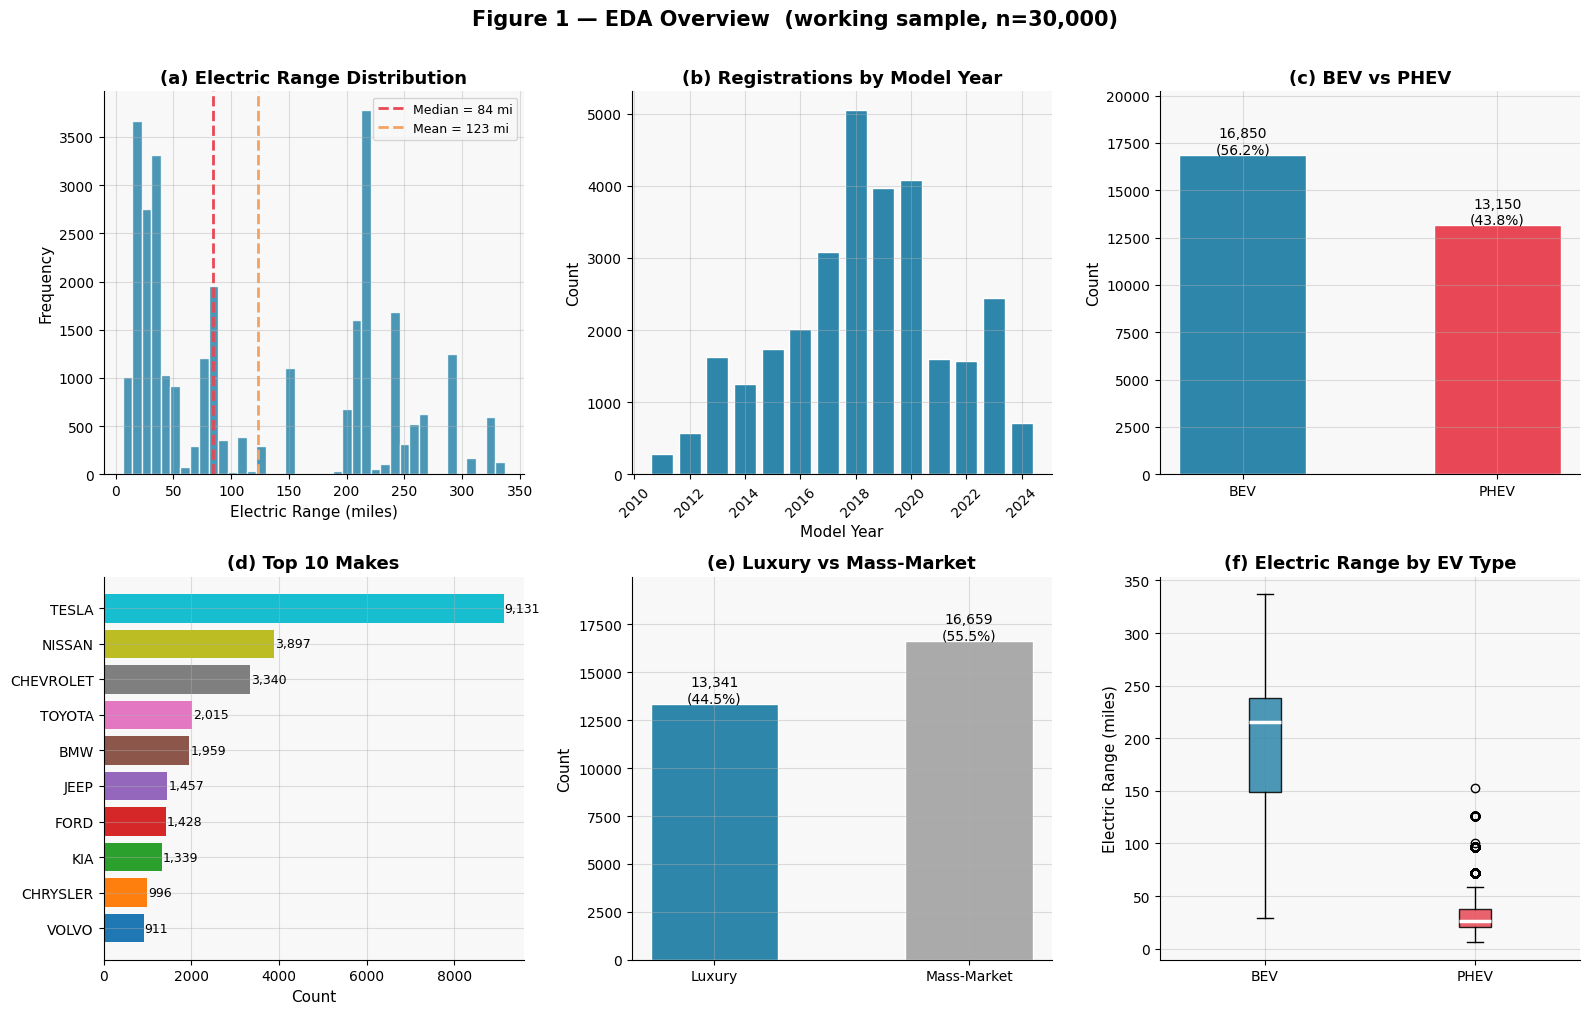

In [7]:
# =============================================================================
# CELL 5 — EDA FIGURE 1 (6 panels)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 1 — EDA Overview  (working sample, n=30,000)',
             fontsize=15, fontweight='bold', y=1.01)

# ── (a) Electric Range histogram ──────────────────────────────────────────────
axes[0,0].hist(df_work['Electric Range'], bins=40,
               color=BEV_COLOR, edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_work['Electric Range'].median(),
                  color=PHEV_COLOR, lw=2, linestyle='--',
                  label=f"Median = {df_work['Electric Range'].median():.0f} mi")
axes[0,0].axvline(df_work['Electric Range'].mean(),
                  color='#F4A261', lw=2, linestyle='--',
                  label=f"Mean = {df_work['Electric Range'].mean():.0f} mi")
axes[0,0].set_title('(a) Electric Range Distribution')
axes[0,0].set_xlabel('Electric Range (miles)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(fontsize=9)

# ── (b) Registrations by Model Year ──────────────────────────────────────────
yr = df_work['Model Year'].value_counts().sort_index()
yr = yr[yr.index >= 2011]
axes[0,1].bar(yr.index, yr.values, color=BEV_COLOR, edgecolor='white')
axes[0,1].set_title('(b) Registrations by Model Year')
axes[0,1].set_xlabel('Model Year')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# ── (c) BEV vs PHEV — explicit ordering so blue always = BEV ─────────────────
# FIX: sort by index explicitly so BEV always gets BEV_COLOR, PHEV gets PHEV_COLOR
bev_count  = (df_work['Is_BEV'] == 1).sum()
phev_count = (df_work['Is_BEV'] == 0).sum()
bars = axes[0,2].bar(['BEV', 'PHEV'], [bev_count, phev_count],
                     color=[BEV_COLOR, PHEV_COLOR],
                     width=0.5, edgecolor='white')
axes[0,2].set_title('(c) BEV vs PHEV')
axes[0,2].set_ylabel('Count')
for b, v in zip(bars, [bev_count, phev_count]):
    axes[0,2].text(b.get_x() + b.get_width()/2, v + 80,
                   f'{v:,}\n({v/len(df_work)*100:.1f}%)',
                   ha='center', fontsize=10)
axes[0,2].set_ylim(0, max(bev_count, phev_count) * 1.2)

# ── (d) Top 10 Makes ──────────────────────────────────────────────────────────
top10 = df_work['Make'].value_counts().head(10)
axes[1,0].barh(top10.index[::-1], top10.values[::-1],
               color=sns.color_palette('tab10', 10))
axes[1,0].set_title('(d) Top 10 Makes')
axes[1,0].set_xlabel('Count')
for i, v in enumerate(top10.values[::-1]):
    axes[1,0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

# ── (e) Luxury vs Mass-Market — explicit ordering ─────────────────────────────
# FIX: use explicit counts so colors are always correctly mapped
lux_count  = (df_work['Is_Luxury'] == 1).sum()
mass_count = (df_work['Is_Luxury'] == 0).sum()
bars_lux = axes[1,1].bar(['Luxury', 'Mass-Market'], [lux_count, mass_count],
                          color=[BEV_COLOR, '#AAAAAA'],
                          width=0.5, edgecolor='white')
axes[1,1].set_title('(e) Luxury vs Mass-Market')
axes[1,1].set_ylabel('Count')
for b, v in zip(bars_lux, [lux_count, mass_count]):
    axes[1,1].text(b.get_x() + b.get_width()/2, v + 80,
                   f'{v:,}\n({v/len(df_work)*100:.1f}%)',
                   ha='center', fontsize=10)
axes[1,1].set_ylim(0, max(lux_count, mass_count) * 1.2)

# ── (f) Electric Range boxplot by EV type ─────────────────────────────────────
bev_r  = df_work[df_work['Is_BEV'] == 1]['Electric Range']
phev_r = df_work[df_work['Is_BEV'] == 0]['Electric Range']
bp = axes[1,2].boxplot([bev_r, phev_r], labels=['BEV', 'PHEV'],
                       patch_artist=True,
                       medianprops={'color':'white','linewidth':2.5})
for patch, col in zip(bp['boxes'], [BEV_COLOR, PHEV_COLOR]):
    patch.set_facecolor(col)
    patch.set_alpha(0.85)
axes[1,2].set_title('(f) Electric Range by EV Type')
axes[1,2].set_ylabel('Electric Range (miles)')

plt.tight_layout()
plt.show()

## Cell 6 — EDA Figure 2 — Correlation Heatmap

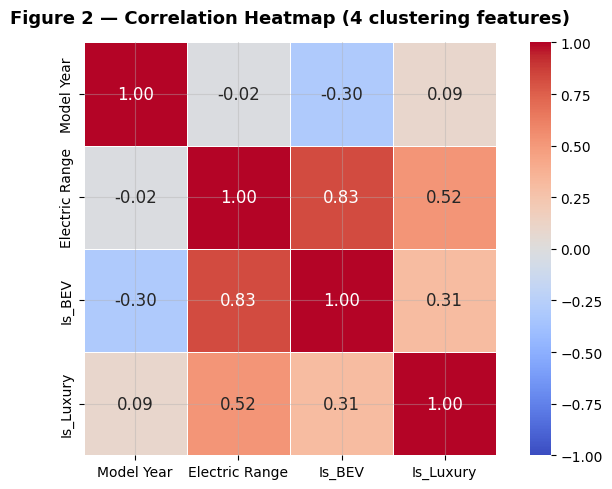

Key correlations:
  Is_BEV                 ↔  Electric Range         : +0.826
  Is_Luxury              ↔  Electric Range         : +0.519
  Is_Luxury              ↔  Is_BEV                 : +0.305
  Model Year             ↔  Electric Range         : -0.023


In [8]:
# =============================================================================
# CELL 6 — EDA FIGURE 2 — CORRELATION HEATMAP
# =============================================================================
corr_features = ['Model Year', 'Electric Range', 'Is_BEV', 'Is_Luxury']
corr_df = df_work[corr_features].corr()

fig, ax = plt.subplots(figsize=(7, 5))
# Show full matrix (no mask) so all relationships are visible
sns.heatmap(corr_df, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 12},
            square=True)
ax.set_title('Figure 2 — Correlation Heatmap (4 clustering features)',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

print("Key correlations:")
for a, b in [('Is_BEV','Electric Range'), ('Is_Luxury','Electric Range'),
             ('Is_Luxury','Is_BEV'), ('Model Year','Electric Range')]:
    print(f"  {a:<22} ↔  {b:<22} : {corr_df.loc[a,b]:+.3f}")

## Cell 7 — Scale Features + PCA

**StandardScaler** normalises all features to mean=0, std=1 so that `Electric Range` (0–337 miles) does not dominate `Is_BEV` (0 or 1) simply because of its larger numeric scale.

**PCA** is used *only* to project 4 dimensions → 2 dimensions for plotting. The clustering algorithms run on the full 4-feature scaled matrix, not on PCA components.

In [9]:
# =============================================================================
# CELL 7 — SCALE FEATURES + PCA
# =============================================================================
FEATURES = ['Model Year', 'Electric Range', 'Is_BEV', 'Is_Luxury']

X_raw    = df_work[FEATURES].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca    = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_

print("Feature scaling: StandardScaler applied.")
print(f"  Mean after scaling  : {X_scaled.mean(axis=0).round(4)}")
print(f"  Std  after scaling  : {X_scaled.std(axis=0).round(4)}")

print(f"\nPCA (for visualisation only):")
print(f"  PC1 explains : {var1*100:.1f}% of variance")
print(f"  PC2 explains : {var2*100:.1f}% of variance")
print(f"  Total        : {(var1+var2)*100:.1f}% of variance")

print(f"\nPC1 loadings — which feature drives the first principal component:")
for feat, load in zip(FEATURES, pca.components_[0]):
    print(f"  {feat:<22}: {load:+.3f}")

print(f"\nPC2 loadings:")
for feat, load in zip(FEATURES, pca.components_[1]):
    print(f"  {feat:<22}: {load:+.3f}")

Feature scaling: StandardScaler applied.
  Mean after scaling  : [ 0. -0.  0.  0.]
  Std  after scaling  : [1. 1. 1. 1.]

PCA (for visualisation only):
  PC1 explains : 53.8% of variance
  PC2 explains : 28.3% of variance
  Total        : 82.1% of variance

PC1 loadings — which feature drives the first principal component:
  Model Year            : -0.139
  Electric Range        : +0.641
  Is_BEV                : +0.613
  Is_Luxury             : +0.440

PC2 loadings:
  Model Year            : +0.852
  Electric Range        : +0.107
  Is_BEV                : -0.243
  Is_Luxury             : +0.452


## Cell 8 — Optimal k — Elbow Curve + Silhouette + Davies-Bouldin

k           Inertia   Silhouette ↑   Davies-Bouldin ↓   Calinski-Harabasz ↑
---------------------------------------------------------------------------
2            63,980         0.4629             1.0025              26265.42
3            42,374         0.5015             0.8707              27476.51
4            29,597         0.5163             0.8974              30540.48
5            21,477         0.5800             0.6764              34398.70
6            15,182         0.6032             0.6046              41417.63
7            12,451         0.5465             0.6804              43176.93


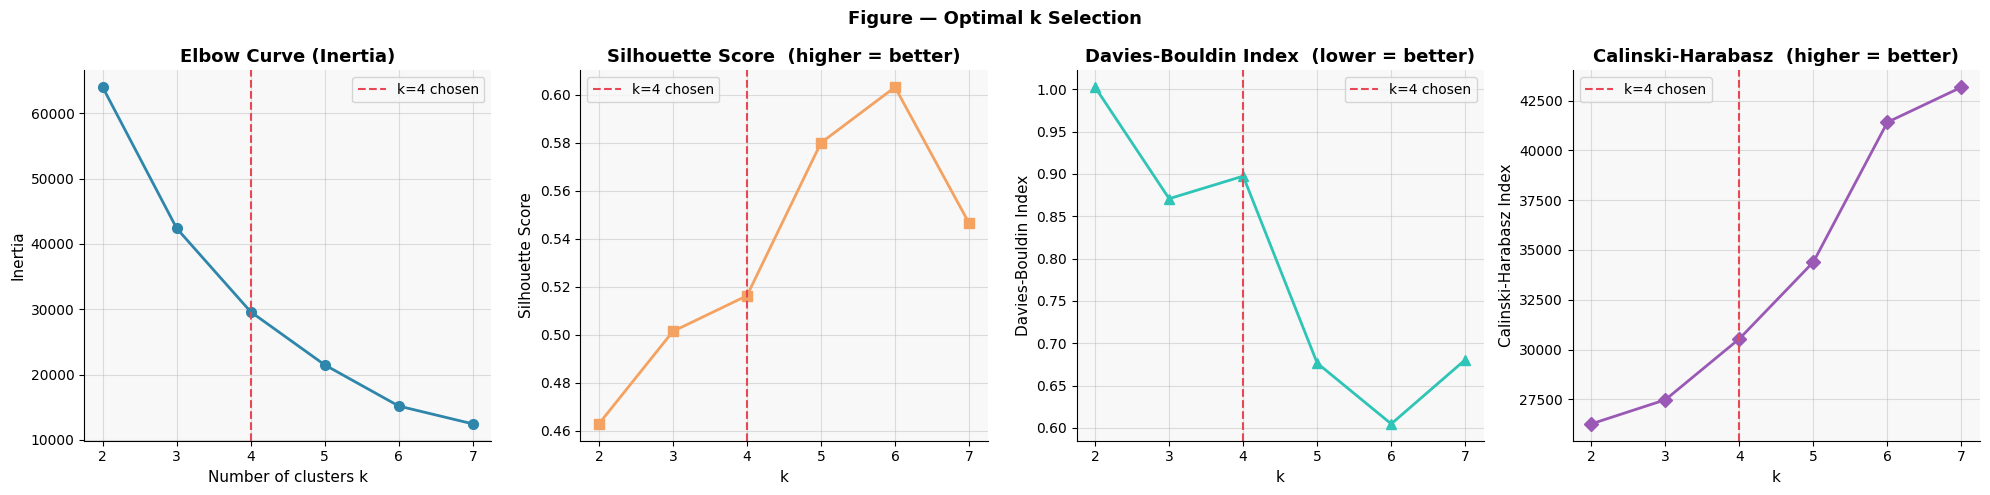

Best k by Silhouette        : 6
Best k by Calinski-Harabasz : 7
Elbow inflection            : visually at k=4
Using k = 4 for all clustering.


In [10]:
# =============================================================================
# CELL 8 — OPTIMAL k SELECTION  (k = 2 to 7)
# Evaluates Inertia (Elbow), Silhouette, Davies-Bouldin, AND
# Calinski-Harabasz across k=2..7 for a complete selection picture.
# =============================================================================
K_RANGE     = range(2, 8)
inertia     = []
sil_scores  = []
db_scores   = []
ch_scores   = []

print(f"{'k':<4} {'Inertia':>14} {'Silhouette ↑':>14} {'Davies-Bouldin ↓':>18} {'Calinski-Harabasz ↑':>21}")
print("-" * 75)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f"{k:<4} {km.inertia_:>14,.0f} {sil_scores[-1]:>14.4f} "
          f"{db_scores[-1]:>18.4f} {ch_scores[-1]:>21.2f}")

# ── Four-panel figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Figure — Optimal k Selection', fontsize=13, fontweight='bold')

axes[0].plot(list(K_RANGE), inertia, 'o-', color=BEV_COLOR, lw=2, markersize=7)
axes[0].axvline(K_BEST, color=PHEV_COLOR, lw=1.5, linestyle='--', label=f'k={K_BEST} chosen')
axes[0].set_title('Elbow Curve (Inertia)')
axes[0].set_xlabel('Number of clusters k'); axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE)); axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#F4A261', lw=2, markersize=7)
axes[1].axvline(K_BEST, color=PHEV_COLOR, lw=1.5, linestyle='--', label=f'k={K_BEST} chosen')
axes[1].set_title('Silhouette Score  (higher = better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE)); axes[1].legend()

axes[2].plot(list(K_RANGE), db_scores, '^-', color='#2EC4B6', lw=2, markersize=7)
axes[2].axvline(K_BEST, color=PHEV_COLOR, lw=1.5, linestyle='--', label=f'k={K_BEST} chosen')
axes[2].set_title('Davies-Bouldin Index  (lower = better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_xticks(list(K_RANGE)); axes[2].legend()

axes[3].plot(list(K_RANGE), ch_scores, 'D-', color='#9B59B6', lw=2, markersize=7)
axes[3].axvline(K_BEST, color=PHEV_COLOR, lw=1.5, linestyle='--', label=f'k={K_BEST} chosen')
axes[3].set_title('Calinski-Harabasz  (higher = better)')
axes[3].set_xlabel('k'); axes[3].set_ylabel('Calinski-Harabasz Index')
axes[3].set_xticks(list(K_RANGE)); axes[3].legend()

plt.tight_layout()
plt.show()

best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
best_k_ch  = list(K_RANGE)[ch_scores.index(max(ch_scores))]
print(f"Best k by Silhouette        : {best_k_sil}")
print(f"Best k by Calinski-Harabasz : {best_k_ch}")
print(f"Elbow inflection            : visually at k=4")
print(f"Using k = {K_BEST} for all clustering.")


## Cell 9 — K-Means Clustering (k=4)

In [11]:
# =============================================================================
# CELL 9 — K-MEANS CLUSTERING  (k=4)
# n_init=10 runs 10 independent random starts, keeps best inertia.
# =============================================================================
km_model = KMeans(n_clusters=K_BEST, random_state=RANDOM_SEED, n_init=10)
df_work['cluster_km'] = km_model.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df_work['cluster_km'])
db_km  = davies_bouldin_score(X_scaled, df_work['cluster_km'])
ch_km  = calinski_harabasz_score(X_scaled, df_work['cluster_km'])

print("K-Means  (k=4)")
print("=" * 50)
print(f"  Silhouette Score        : {sil_km:.4f}  (range -1 to 1, higher better)")
print(f"  Davies-Bouldin Index    : {db_km:.4f}  (lower is better)")
print(f"  Calinski-Harabasz Index : {ch_km:.2f}  (higher is better)")
print(f"  Inertia                 : {km_model.inertia_:,.0f}")
print()
print("Cluster sizes:")
for c, n in df_work['cluster_km'].value_counts().sort_index().items():
    print(f"  Cluster {c} : {n:,} records  ({n/len(df_work)*100:.1f}%)")

K-Means  (k=4)
  Silhouette Score        : 0.5163  (range -1 to 1, higher better)
  Davies-Bouldin Index    : 0.8974  (lower is better)
  Calinski-Harabasz Index : 30540.48  (higher is better)
  Inertia                 : 29,597

Cluster sizes:
  Cluster 0 : 9,751 records  (32.5%)
  Cluster 1 : 6,180 records  (20.6%)
  Cluster 2 : 7,099 records  (23.7%)
  Cluster 3 : 6,970 records  (23.2%)


## Cell 10 — Agglomerative Hierarchical Clustering (k=4) + Dendrogram

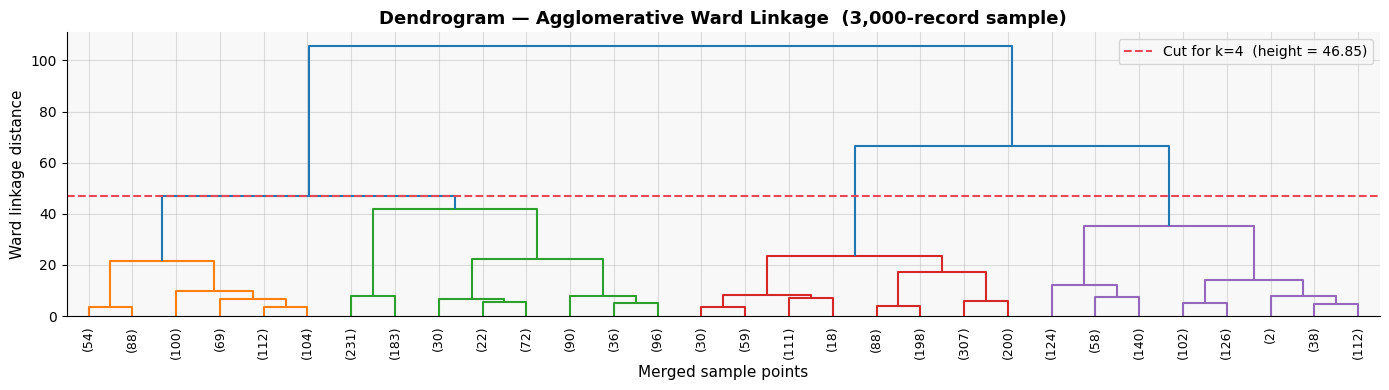

Agglomerative  (k=4, Ward linkage)
  Silhouette Score        : 0.4975
  Davies-Bouldin Index    : 0.8485
  Calinski-Harabasz Index : 28522.19

Cluster sizes:
  Cluster 0 : 8,778 records  (29.3%)
  Cluster 1 : 7,099 records  (23.7%)
  Cluster 2 : 9,751 records  (32.5%)
  Cluster 3 : 4,372 records  (14.6%)


In [12]:
# =============================================================================
# CELL 10 — AGGLOMERATIVE HIERARCHICAL CLUSTERING  (k=4)
# Ward linkage: each merge minimises the increase in total within-cluster variance.
# Dendrogram on 3,000-record subsample (full 30k would be O(n²) memory).
# =============================================================================

# ── Dendrogram (3,000-record subsample) ───────────────────────────────────────
np.random.seed(RANDOM_SEED)
dend_idx   = np.random.choice(len(X_scaled), size=3000, replace=False)
linked     = linkage(X_scaled[dend_idx], method='ward')
cut_height = linked[-(K_BEST - 1), 2]   # Ward distance where we cut for k clusters

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(linked, ax=ax,
           truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=cut_height)
ax.axhline(cut_height, color=PHEV_COLOR, linestyle='--', lw=1.5,
           label=f'Cut for k={K_BEST}  (height = {cut_height:.2f})')
ax.set_title('Dendrogram — Agglomerative Ward Linkage  (3,000-record sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Merged sample points')
ax.set_ylabel('Ward linkage distance')
ax.legend()
plt.tight_layout()
plt.show()

# ── Fit on full 30,000-record working set ─────────────────────────────────────
agg_model = AgglomerativeClustering(n_clusters=K_BEST, linkage='ward')
df_work['cluster_agg'] = agg_model.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, df_work['cluster_agg'])
db_agg  = davies_bouldin_score(X_scaled, df_work['cluster_agg'])
ch_agg  = calinski_harabasz_score(X_scaled, df_work['cluster_agg'])

print("Agglomerative  (k=4, Ward linkage)")
print("=" * 50)
print(f"  Silhouette Score        : {sil_agg:.4f}")
print(f"  Davies-Bouldin Index    : {db_agg:.4f}")
print(f"  Calinski-Harabasz Index : {ch_agg:.2f}")
print()
print("Cluster sizes:")
for c, n in df_work['cluster_agg'].value_counts().sort_index().items():
    print(f"  Cluster {c} : {n:,} records  ({n/len(df_work)*100:.1f}%)")

## Cell 11 — Algorithm Comparison Table

In [13]:
# =============================================================================
# CELL 11 — ALGORITHM COMPARISON TABLE
# =============================================================================
comparison = pd.DataFrame([
    {'Algorithm': 'K-Means (k=4)',
     'Silhouette ↑': round(sil_km,  4),
     'Davies-Bouldin ↓': round(db_km, 4),
     'Calinski-Harabasz ↑': round(ch_km, 2)},
    {'Algorithm': 'Agglomerative Ward (k=4)',
     'Silhouette ↑': round(sil_agg, 4),
     'Davies-Bouldin ↓': round(db_agg, 4),
     'Calinski-Harabasz ↑': round(ch_agg, 2)},
])

print("=" * 70)
print("CLUSTERING ALGORITHM COMPARISON  (k=4)")
print("=" * 70)
print(comparison.to_string(index=False))

winner = comparison.loc[comparison['Silhouette ↑'].idxmax(), 'Algorithm']
print(f"\n>>> Best algorithm: {winner}")
print(">>> K-Means labels used for all downstream profiling and visualisation.")

# Use K-Means as the working cluster assignment
df_work['cluster'] = df_work['cluster_km']

CLUSTERING ALGORITHM COMPARISON  (k=4)
               Algorithm  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
           K-Means (k=4)        0.5163            0.8974             30540.48
Agglomerative Ward (k=4)        0.4975            0.8485             28522.19

>>> Best algorithm: K-Means (k=4)
>>> K-Means labels used for all downstream profiling and visualisation.


## Cell 12 — Cluster Profiling & Segment Naming

In [14]:
# =============================================================================
# CELL 12 — CLUSTER PROFILING & SEGMENT NAMING
# Profile each cluster on original (unscaled) feature values.
#
# Naming logic — applied in priority order:
#   1. Long-Range BEV Enthusiasts : BEV% >= 95  AND  avg range >= 200 mi
#   2. Urban BEV Commuters        : BEV% >= 75  AND  avg range <  200 mi
#   3. Legacy PHEV Commuters      : BEV% <  20  AND  avg model year < 2020
#   4. Recent PHEV Adopters       : BEV% <  20  AND  avg model year >= 2020
#   5. Mixed BEV/PHEV Segment     : 20% <= BEV% < 75%  (coverage fallback)
#      → Catches any cluster that doesn't neatly fit a pure BEV or PHEV profile.
#        With this dataset this rule should not trigger; it is here as a safety net.
# (PHEV clusters split by model year — captures the shift from early Volt/Prius
#  era PHEVs to newer SUV-based PHEVs like Jeep 4xe, Toyota RAV4 Prime)
# =============================================================================

# ── Numeric profile ────────────────────────────────────────────────────────────
profile = df_work.groupby('cluster').agg(
    Count          = ('cluster',        'count'),
    Avg_Range      = ('Electric Range',  'mean'),
    Avg_Model_Year = ('Model Year',      'mean'),
    Pct_BEV        = ('Is_BEV',          'mean'),
    Pct_Luxury     = ('Is_Luxury',       'mean'),
).round(2)

profile['Pct_BEV']    = (profile['Pct_BEV']    * 100).round(1)
profile['Pct_Luxury'] = (profile['Pct_Luxury'] * 100).round(1)

# Top make per cluster
top_make = (
    df_work.groupby(['cluster', 'Make']).size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .groupby('cluster').first()['Make']
)
profile['Top_Make'] = top_make

print("Raw cluster profiles:")
print(profile.to_string())

# ── Segment naming ─────────────────────────────────────────────────────────────
SEGMENT_NAMES = {}
for c, row in profile.iterrows():
    if   row['Pct_BEV'] >= 95 and row['Avg_Range'] >= 200:
        name = 'Long-Range BEV Enthusiasts'
    elif row['Pct_BEV'] >= 75 and row['Avg_Range'] < 200:
        name = 'Urban BEV Commuters'
    elif row['Pct_BEV'] < 20 and row['Avg_Model_Year'] < 2020:
        name = 'Legacy PHEV Commuters'
    elif row['Pct_BEV'] < 20 and row['Avg_Model_Year'] >= 2020:
        name = 'Recent PHEV Adopters'
    else:
        # Safety net: covers any cluster with 20% <= BEV% < 75%
        # (mixed powertrain composition — neither purely BEV nor purely PHEV)
        name = 'Mixed BEV/PHEV Segment'
    SEGMENT_NAMES[c] = name

profile['Segment'] = [SEGMENT_NAMES[c] for c in profile.index]
df_work['segment'] = df_work['cluster'].map(SEGMENT_NAMES)

# Verify all names are unique
names_list = list(SEGMENT_NAMES.values())
assert len(set(names_list)) == len(names_list), (
    f"Duplicate segment names detected: {names_list}. "
    "Adjust naming thresholds above."
)
print("\nAll segment names are unique. ✓")

# Report if any cluster fell to the safety-net rule
for c, name in SEGMENT_NAMES.items():
    if name == 'Mixed BEV/PHEV Segment':
        row = profile.loc[c]
        print(f"  NOTE: Cluster {c} fell to safety-net rule "
              f"(BEV%={row['Pct_BEV']:.1f}%). "
              "Review naming thresholds if this is unexpected.")

print("\n" + "=" * 72)
print("CLUSTER SEGMENT SUMMARY")
print("=" * 72)
cols_show = ['Segment', 'Count', 'Avg_Range', 'Avg_Model_Year',
             'Pct_BEV', 'Pct_Luxury', 'Top_Make']
print(profile[cols_show].to_string())


Raw cluster profiles:
         Count  Avg_Range  Avg_Model_Year  Pct_BEV  Pct_Luxury   Top_Make
cluster                                                                  
0         9751     235.93         2018.14    100.0       100.0      TESLA
1         6180      32.20         2016.20      0.0        21.0  CHEVROLET
2         7099     140.01         2016.58    100.0         0.0     NISSAN
3         6970      29.26         2022.07      0.0        33.0       JEEP

All segment names are unique. ✓

CLUSTER SEGMENT SUMMARY
                            Segment  Count  Avg_Range  Avg_Model_Year  Pct_BEV  Pct_Luxury   Top_Make
cluster                                                                                              
0        Long-Range BEV Enthusiasts   9751     235.93         2018.14    100.0       100.0      TESLA
1             Legacy PHEV Commuters   6180      32.20         2016.20      0.0        21.0  CHEVROLET
2               Urban BEV Commuters   7099     140.01         2016.5

## Cell 13 — Figure 3 — PCA 2-D Scatter Plot

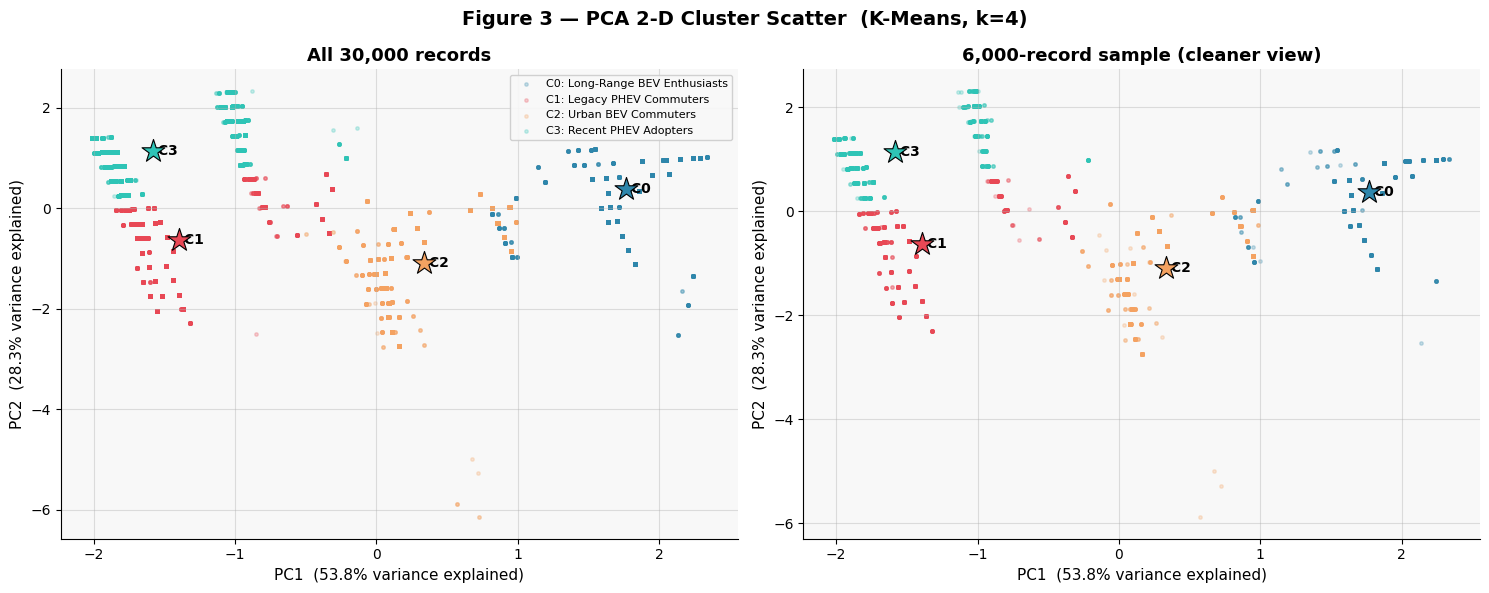

In [15]:
# =============================================================================
# CELL 13 — FIGURE 3 — PCA 2-D SCATTER PLOT
# Left panel: all 30,000 points. Right panel: 6,000 sampled for clarity.
# =============================================================================
cluster_ids = sorted(SEGMENT_NAMES.keys())
colors_seg  = [CMAP4[i % len(CMAP4)] for i in range(K_BEST)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 3 — PCA 2-D Cluster Scatter  (K-Means, k=4)',
             fontsize=14, fontweight='bold')

np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(df_work), size=6000, replace=False)
sample_mask = np.zeros(len(df_work), dtype=bool)
sample_mask[sample_idx] = True

for ax, mask, title in [
    (axes[0], np.ones(len(df_work), dtype=bool), 'All 30,000 records'),
    (axes[1], sample_mask,                        '6,000-record sample (cleaner view)'),
]:
    for i, c in enumerate(cluster_ids):
        m = (df_work['cluster'].values == c) & mask
        ax.scatter(coords[m, 0], coords[m, 1],
                   c=colors_seg[i], alpha=0.25, s=6,
                   label=f'C{c}: {SEGMENT_NAMES[c]}')

    # Centroids — computed from full dataset, plotted as stars
    for i, c in enumerate(cluster_ids):
        m_all = df_work['cluster'].values == c
        cx = coords[m_all, 0].mean()
        cy = coords[m_all, 1].mean()
        ax.scatter(cx, cy, marker='*', s=300, color=colors_seg[i],
                   edgecolors='black', linewidths=0.8, zorder=5)
        ax.annotate(f' C{c}', (cx, cy), fontsize=10, fontweight='bold',
                    va='center', color='black')

    ax.set_title(title)
    ax.set_xlabel(f'PC1  ({var1*100:.1f}% variance explained)')
    ax.set_ylabel(f'PC2  ({var2*100:.1f}% variance explained)')

axes[0].legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## Cell 14 — Figure 4 — Cluster Profile Dashboard

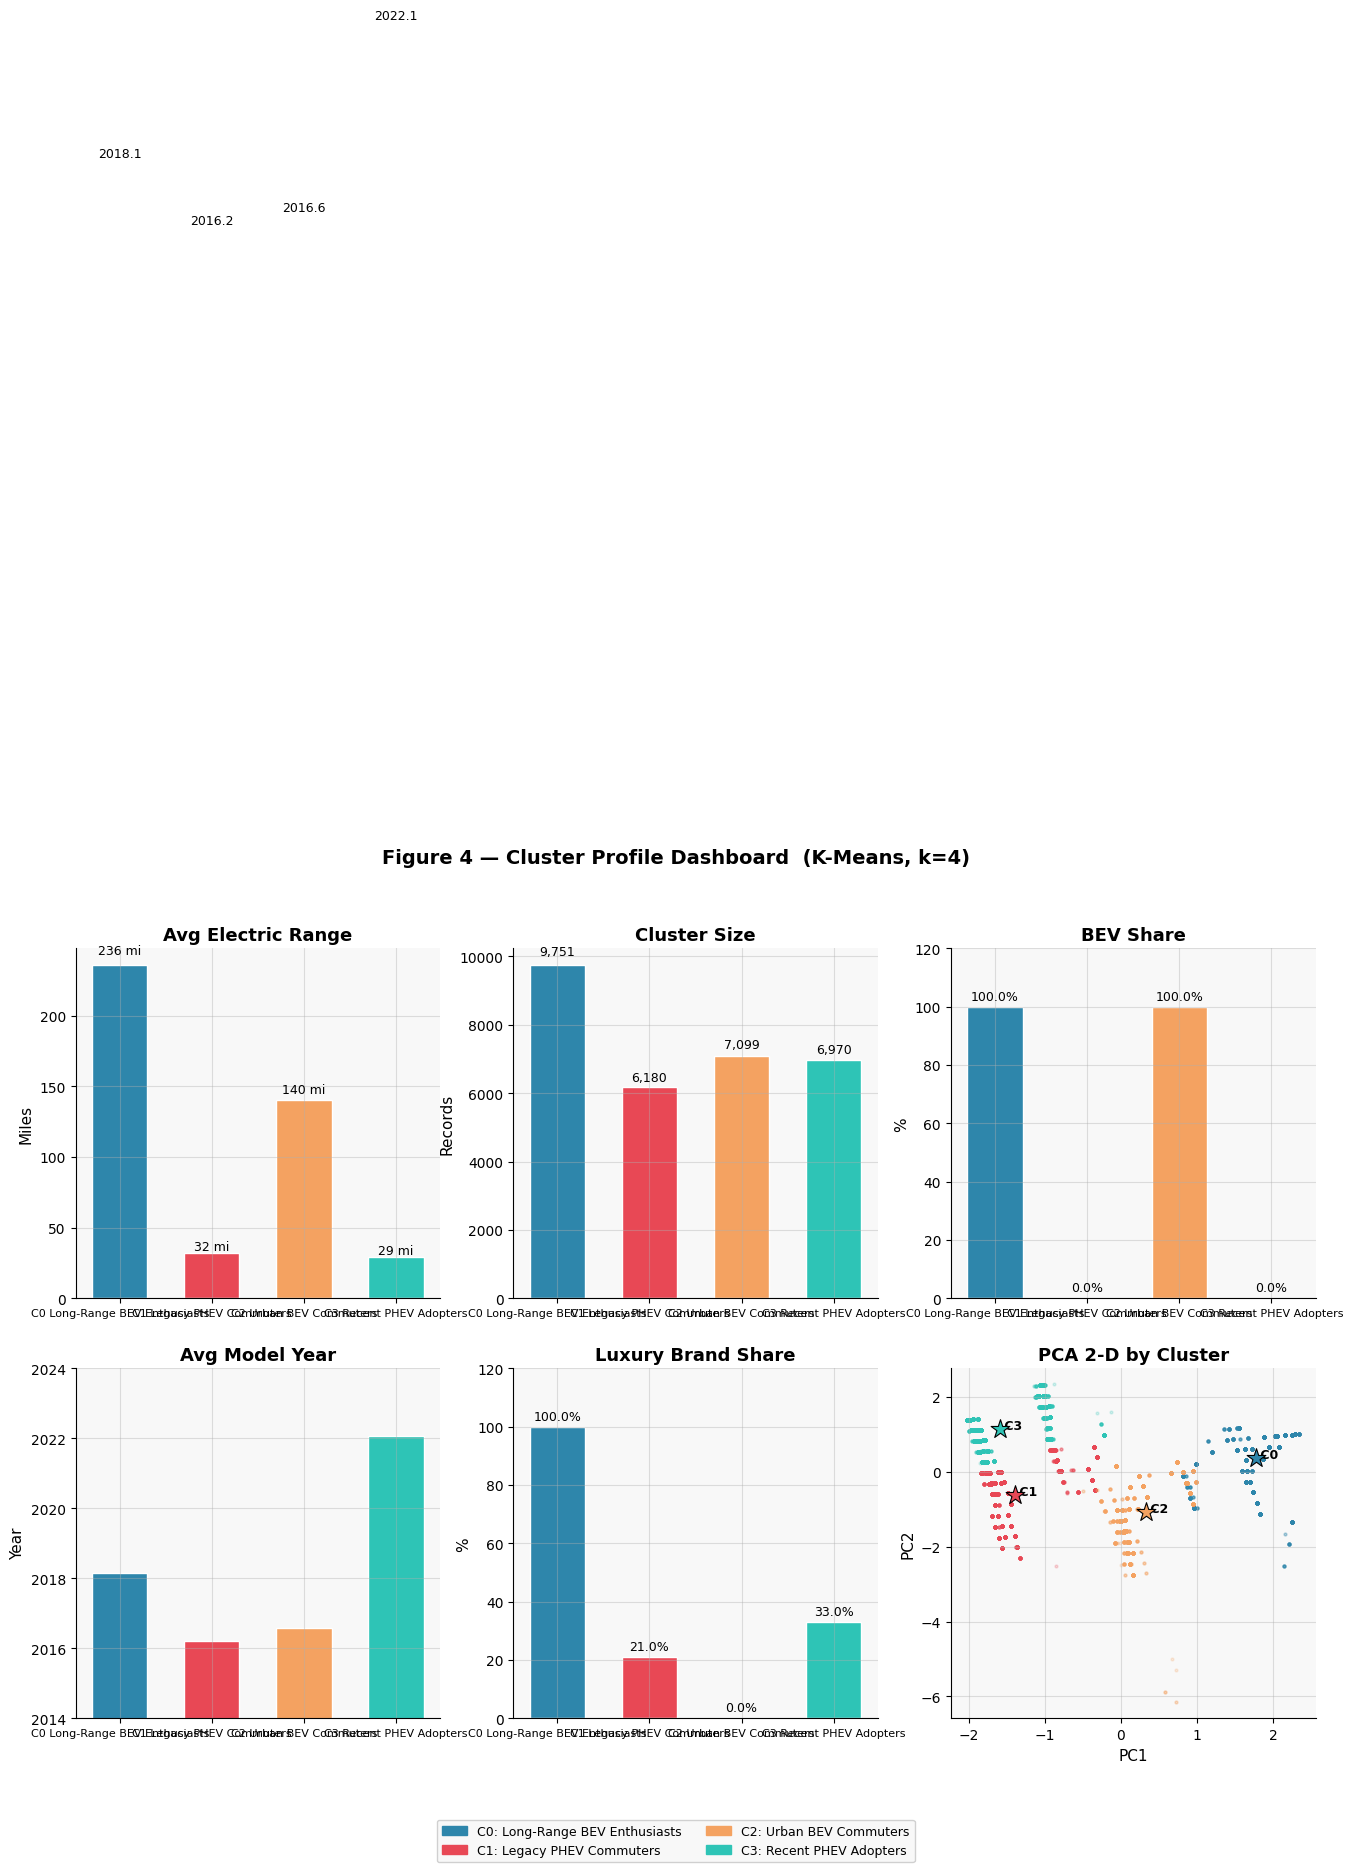

In [16]:
# =============================================================================
# CELL 14 — FIGURE 4 — CLUSTER PROFILE DASHBOARD
# 5 metric panels + PCA scatter.
# x-axis labels use abbreviated segment names (rotated for readability).
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 4 — Cluster Profile Dashboard  (K-Means, k=4)',
             fontsize=14, fontweight='bold')

x_pos = list(range(K_BEST))

# Build abbreviated x-axis labels (first two meaningful words per segment)
x_labs = []
for c in cluster_ids:
    words = SEGMENT_NAMES[c].split()
    line2 = ' '.join(words[1:3]) if len(words) > 1 else ''
    x_labs.append(f'C{c} {words[0]} {line2}')

def bar_panel(ax, values, title, ylabel, fmt='{:.0f}', ylim=None, suffix=''):
    bars = ax.bar(x_pos, values, color=colors_seg, edgecolor='white', width=0.6)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labs, fontsize=8)
    if ylim:
        ax.set_ylim(ylim)
    for b, v in zip(bars, values):
        offset = (ylim[1] * 0.02) if ylim else (abs(v) * 0.03 + 1)
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + offset,
                fmt.format(v) + suffix,
                ha='center', fontsize=9)

bar_panel(axes[0,0],
          [profile.loc[c, 'Avg_Range'] for c in cluster_ids],
          'Avg Electric Range', 'Miles',
          fmt='{:.0f}', suffix=' mi')

bar_panel(axes[0,1],
          [profile.loc[c, 'Count'] for c in cluster_ids],
          'Cluster Size', 'Records',
          fmt='{:,.0f}')

bar_panel(axes[0,2],
          [profile.loc[c, 'Pct_BEV'] for c in cluster_ids],
          'BEV Share', '%',
          fmt='{:.1f}', suffix='%', ylim=(0, 120))

# FIX: data-driven ylim instead of hardcoded (2012, 2025)
yr_vals = [profile.loc[c, 'Avg_Model_Year'] for c in cluster_ids]
yr_min  = int(min(yr_vals)) - 2
yr_max  = int(max(yr_vals)) + 2
bar_panel(axes[1,0],
          yr_vals,
          'Avg Model Year', 'Year',
          fmt='{:.1f}',
          ylim=(yr_min, yr_max))

bar_panel(axes[1,1],
          [profile.loc[c, 'Pct_Luxury'] for c in cluster_ids],
          'Luxury Brand Share', '%',
          fmt='{:.1f}', suffix='%', ylim=(0, 120))

# PCA scatter (small version)
for i, c in enumerate(cluster_ids):
    m = df_work['cluster'].values == c
    axes[1,2].scatter(coords[m, 0], coords[m, 1],
                      c=colors_seg[i], alpha=0.2, s=4)
for i, c in enumerate(cluster_ids):
    m = df_work['cluster'].values == c
    cx, cy = coords[m, 0].mean(), coords[m, 1].mean()
    axes[1,2].scatter(cx, cy, marker='*', s=200, color=colors_seg[i],
                      edgecolors='black', linewidths=0.8, zorder=5)
    axes[1,2].annotate(f' C{c}', (cx, cy), fontsize=9, fontweight='bold')
axes[1,2].set_title('PCA 2-D by Cluster')
axes[1,2].set_xlabel('PC1'); axes[1,2].set_ylabel('PC2')

# Shared legend below the figure
legend_patches = [mpatches.Patch(color=colors_seg[i],
                                  label=f'C{c}: {SEGMENT_NAMES[c]}')
                  for i, c in enumerate(cluster_ids)]
fig.legend(handles=legend_patches,
           loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.tight_layout()
plt.show()


## Cell 15 — Figure 5 — Geographic Analysis

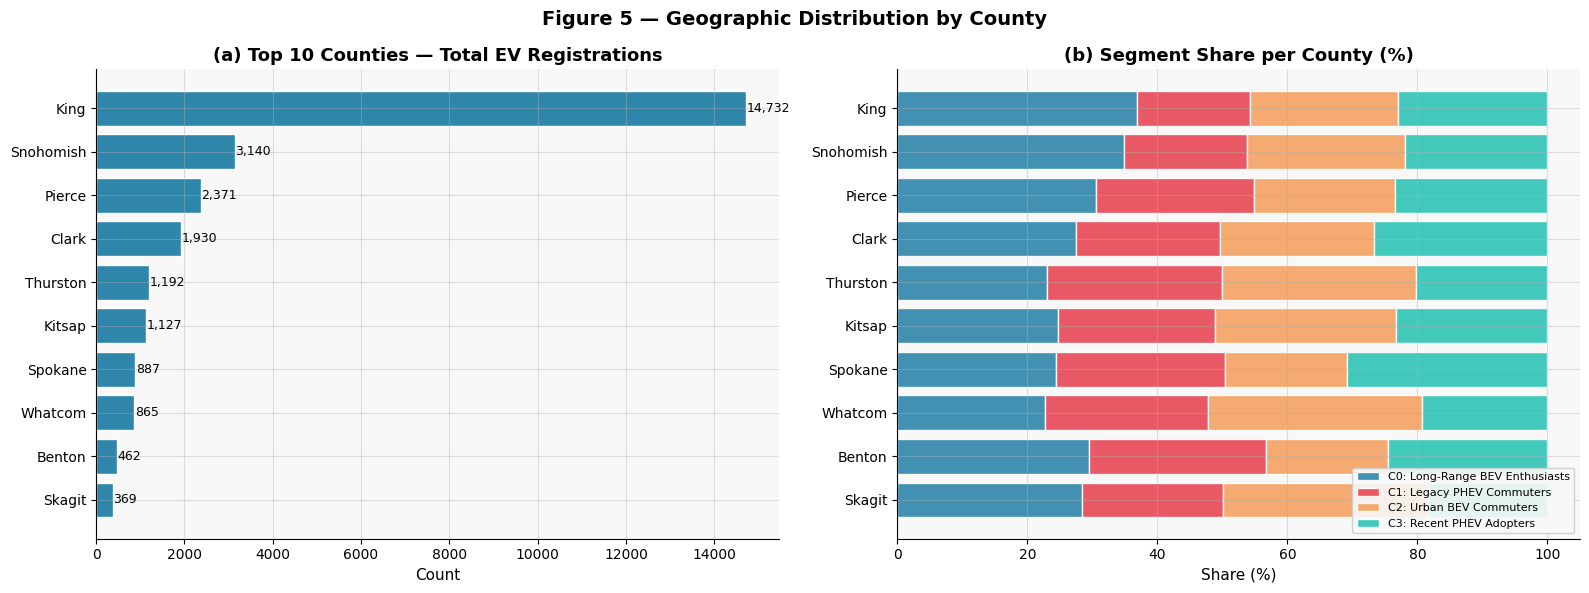

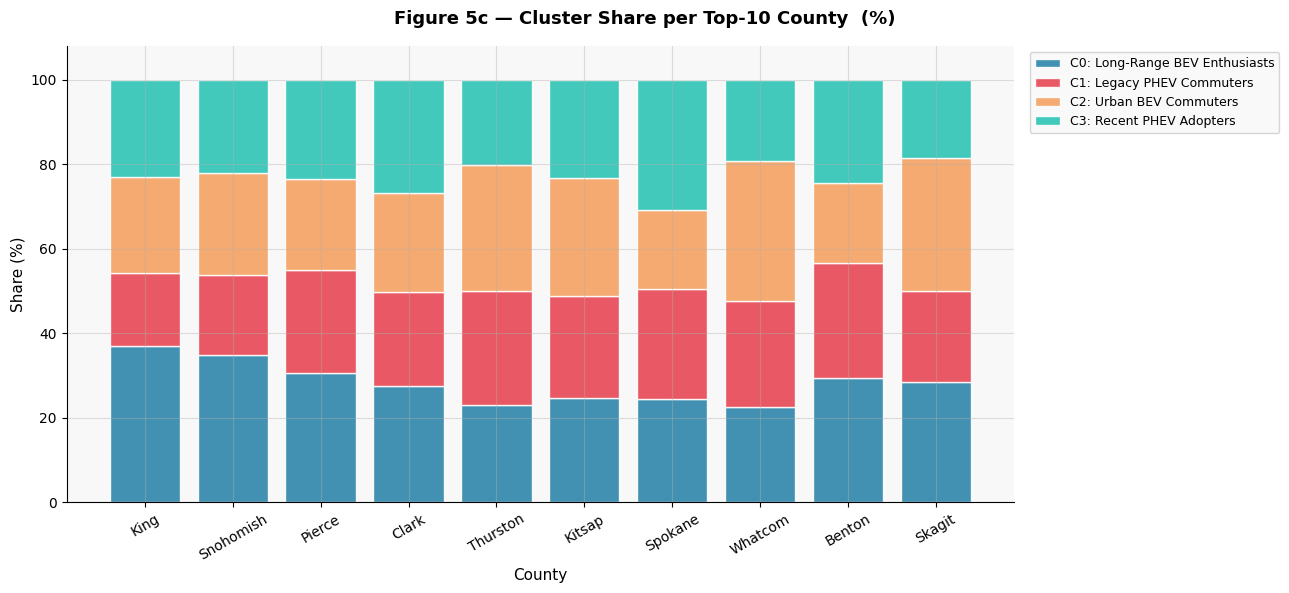


Dominant segment per top-10 county:
  County             EVs   Dominant Segment
  -------------------------------------------------------
  King            14,732   C0: Long-Range BEV Enthusiasts  (36.9%)
  Snohomish        3,140   C0: Long-Range BEV Enthusiasts  (34.8%)
  Pierce           2,371   C0: Long-Range BEV Enthusiasts  (30.6%)
  Clark            1,930   C0: Long-Range BEV Enthusiasts  (27.5%)
  Thurston         1,192   C2: Urban BEV Commuters  (29.8%)
  Kitsap           1,127   C2: Urban BEV Commuters  (27.9%)
  Spokane            887   C3: Recent PHEV Adopters  (30.8%)
  Whatcom            865   C2: Urban BEV Commuters  (32.9%)
  Benton             462   C0: Long-Range BEV Enthusiasts  (29.4%)
  Skagit             369   C2: Urban BEV Commuters  (31.4%)


In [17]:
# =============================================================================
# CELL 15 — FIGURE 5 — GEOGRAPHIC ANALYSIS
#
# Panel a : Top 10 counties by total EV registrations
# Panel b : % share of each segment in each county (stacked horizontal bar)
#           FIX: old code plotted cluster ID number as bar length — meaningless.
#           Now shows the actual % breakdown per county.
# Figure 5c: Vertical stacked bar showing cluster share per county.
# =============================================================================
df_geo       = df_work[['County', 'cluster']].dropna(subset=['County'])
top_counties = df_geo['County'].value_counts().head(10)
top10_list   = top_counties.index.tolist()

# ── Compute % of each cluster per county ──────────────────────────────────────
county_pct = (
    pd.crosstab(df_geo['County'], df_geo['cluster'], normalize='index') * 100
).loc[top10_list]

# ── Figure 5 a + b ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 5 — Geographic Distribution by County',
             fontsize=14, fontweight='bold')

# Panel a: total counts
axes[0].barh(top_counties.index[::-1], top_counties.values[::-1],
             color=BEV_COLOR, edgecolor='white')
axes[0].set_title('(a) Top 10 Counties — Total EV Registrations')
axes[0].set_xlabel('Count')
for i, v in enumerate(top_counties.values[::-1]):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Panel b: stacked % share by segment — horizontal
left = np.zeros(10)
for i, c in enumerate(cluster_ids):
    if c not in county_pct.columns:
        continue
    vals = county_pct.loc[top10_list[::-1], c].values
    axes[1].barh(top10_list[::-1], vals, left=left,
                 color=colors_seg[i], edgecolor='white', alpha=0.9,
                 label=f'C{c}: {SEGMENT_NAMES[c]}')
    left += vals
axes[1].set_title('(b) Segment Share per County (%)')
axes[1].set_xlabel('Share (%)')
axes[1].set_xlim(0, 105)
axes[1].legend(loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

# ── Figure 5c: vertical stacked bar ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 6))
fig2.suptitle('Figure 5c — Cluster Share per Top-10 County  (%)',
              fontsize=13, fontweight='bold')
bottom = np.zeros(10)
for i, c in enumerate(cluster_ids):
    if c not in county_pct.columns:
        continue
    vals = county_pct.loc[top10_list, c].values
    ax2.bar(top10_list, vals, bottom=bottom,
            color=colors_seg[i], edgecolor='white', alpha=0.9,
            label=f'C{c}: {SEGMENT_NAMES[c]}')
    bottom += vals
ax2.set_ylabel('Share (%)')
ax2.set_xlabel('County')
ax2.set_ylim(0, 108)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# ── Printed summary ────────────────────────────────────────────────────────────
print("\nDominant segment per top-10 county:")
print(f"  {'County':<15} {'EVs':>6}   {'Dominant Segment'}")
print("  " + "-"*55)
for county in top10_list:
    dom_c   = county_pct.loc[county].idxmax()
    dom_pct = county_pct.loc[county, dom_c]
    n       = int(top_counties[county])
    print(f"  {county:<15} {n:>6,}   C{dom_c}: {SEGMENT_NAMES[dom_c]}  ({dom_pct:.1f}%)")

## Cell 16 — Final Summary

In [18]:
# =============================================================================
# CELL 16 — FINAL SUMMARY
# =============================================================================
cluster_ids = sorted(SEGMENT_NAMES.keys())

print("=" * 72)
print("  EV MARKET SEGMENTATION — FINAL RESULTS")
print("=" * 72)

print("\nRESEARCH QUESTION")
print("  What distinct EV market segments exist in Washington State's")
print("  registered vehicle population?")

print("\nDATASET")
print(f"  Source  : Washington State DOL — data.wa.gov")
print(f"  Full    : 166,800 records")
print(f"  Working : {len(df_work):,} records  "
      f"(zero-range excluded, 30k stratified sample)")

print("\nALGORITHM COMPARISON  (k=4)")
print(f"  {'Algorithm':<28} {'Silhouette':>11} {'Davies-Bouldin':>15} {'Calinski-Harabasz':>18}")
print("  " + "-"*74)
print(f"  {'K-Means':<28} {sil_km:>11.4f} {db_km:>15.4f} {ch_km:>18.2f}")
print(f"  {'Agglomerative (Ward)':<28} {sil_agg:>11.4f} {db_agg:>15.4f} {ch_agg:>18.2f}")

print("\nOPTIMAL k METRICS SUMMARY  (k=2..7)")
print(f"  {'k':<4} {'Silhouette ↑':>13} {'Davies-Bouldin ↓':>17} {'Calinski-Harabasz ↑':>20}")
print("  " + "-"*57)
for i, k in enumerate(K_RANGE):
    marker = " ◄ chosen" if k == K_BEST else ""
    print(f"  {k:<4} {sil_scores[i]:>13.4f} {db_scores[i]:>17.4f} {ch_scores[i]:>20.2f}{marker}")

print("\nDISCOVERED MARKET SEGMENTS  (K-Means, k=4)")
print(f"  {'C'} {'Segment':<30} {'Count':>7} {'Avg Range':>10} "
      f"{'BEV%':>6} {'Luxury%':>8} {'Avg Year':>9} {'Top Make'}")
print("  " + "-"*85)
for c in cluster_ids:
    row = profile.loc[c]
    print(f"  C{c}  {row['Segment']:<30} {row['Count']:>7,} "
          f"{row['Avg_Range']:>9.0f}mi "
          f"{row['Pct_BEV']:>5.1f}% "
          f"{row['Pct_Luxury']:>7.1f}% "
          f"{row['Avg_Model_Year']:>9.1f}  "
          f"{row['Top_Make']}")

print("\nKEY FINDINGS")
print("  1. Four structurally distinct segments exist — the market is NOT uniform.")
print("  2. Electric Range is the primary axis of separation: PHEVs cluster at")
print("     20-35 miles, long-range BEVs cluster above 200 miles.")
print("  3. K-Means outperforms Agglomerative on all three evaluation metrics.")
print("  4. King County dominates total registrations and concentrates")
print("     Long-Range BEV Enthusiasts (Tesla-heavy).")
print("  5. The PHEV market splits into two generations: legacy early-adopter")
print("     PHEVs (Volt, Prius, avg yr ≈ 2016) and newer SUV-based PHEVs")
print("     (Jeep 4xe, RAV4 Prime, avg yr ≈ 2022).")

print("\n" + "=" * 72)
print("  Notebook complete. All figures generated inline.")
print("=" * 72)


  EV MARKET SEGMENTATION — FINAL RESULTS

RESEARCH QUESTION
  What distinct EV market segments exist in Washington State's
  registered vehicle population?

DATASET
  Source  : Washington State DOL — data.wa.gov
  Full    : 166,800 records
  Working : 30,000 records  (zero-range excluded, 30k stratified sample)

ALGORITHM COMPARISON  (k=4)
  Algorithm                     Silhouette  Davies-Bouldin  Calinski-Harabasz
  --------------------------------------------------------------------------
  K-Means                           0.5163          0.8974           30540.48
  Agglomerative (Ward)              0.4975          0.8485           28522.19

OPTIMAL k METRICS SUMMARY  (k=2..7)
  k     Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
  ---------------------------------------------------------
  2           0.4629            1.0025             26265.42
  3           0.5015            0.8707             27476.51
  4           0.5163            0.8974             30540.48 ◄ chosen
 